<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/HW_10_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота №10
Манзар Л.В.

Файл успішно завантажено!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1),

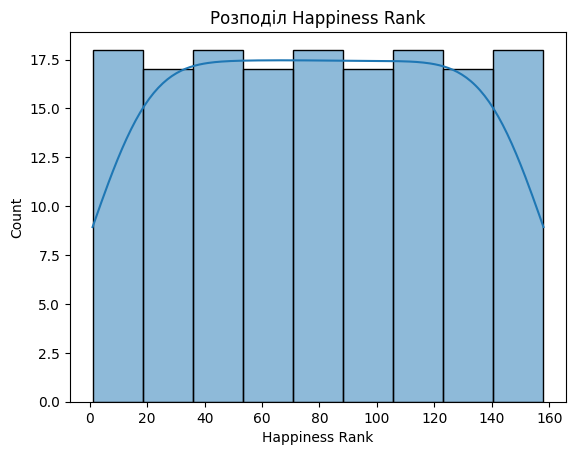

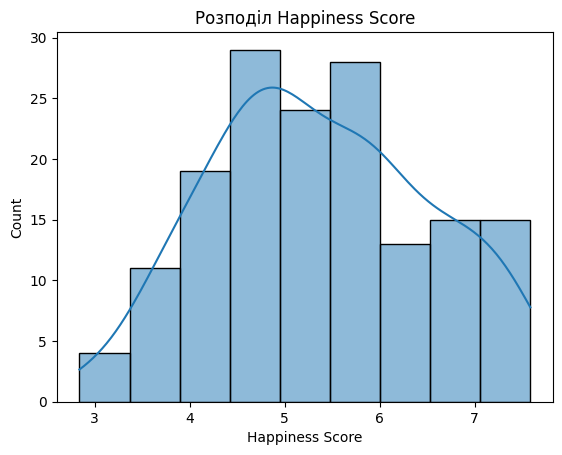

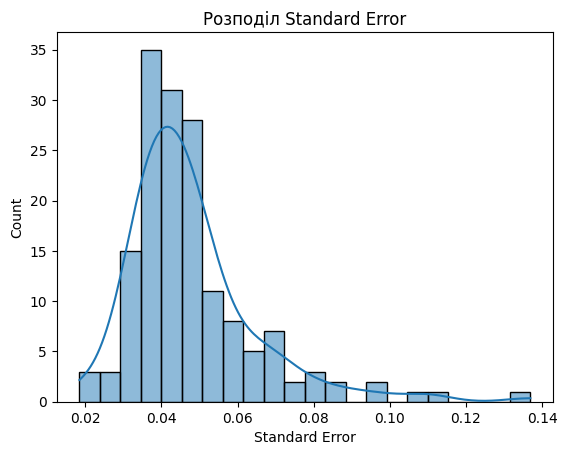

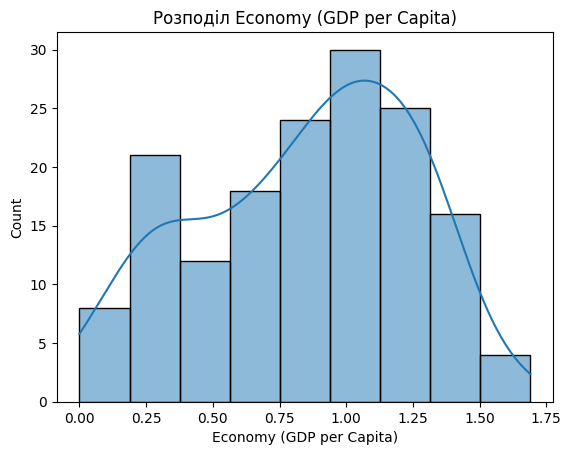

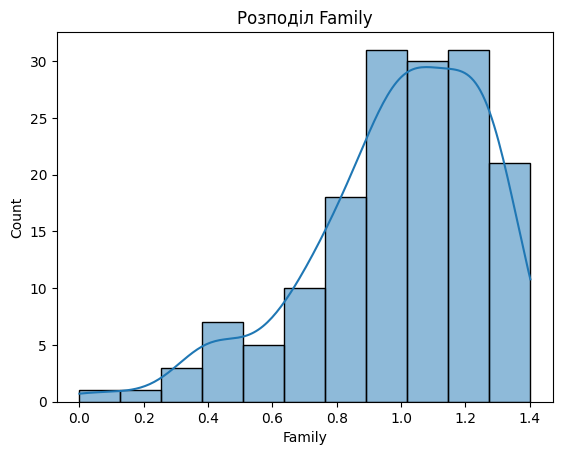

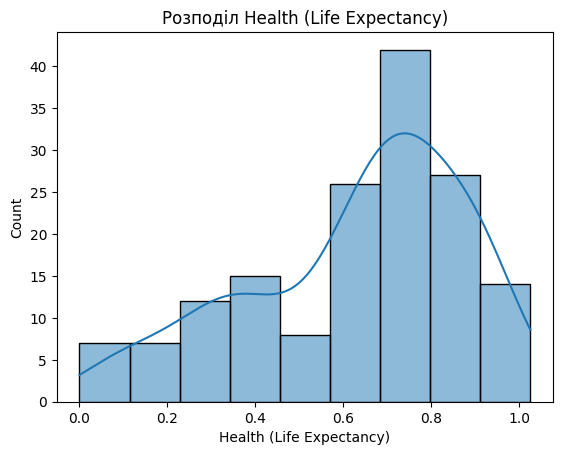

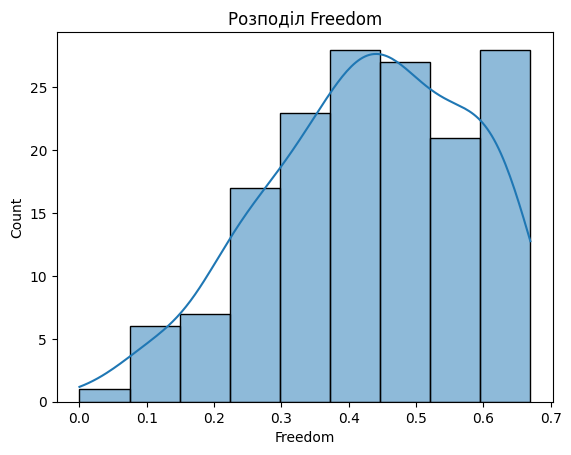

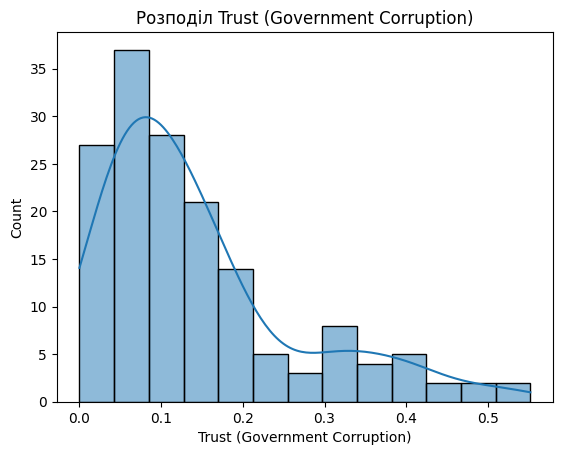

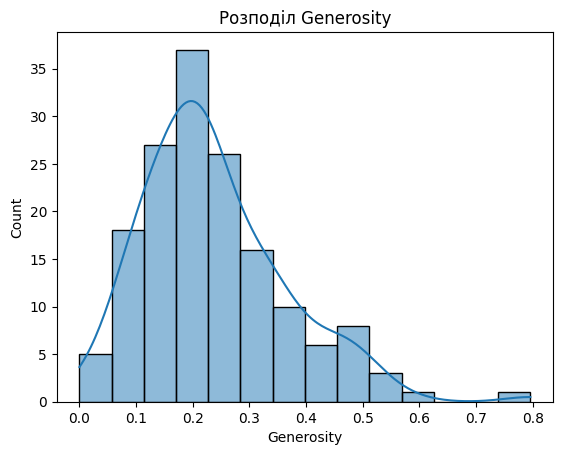

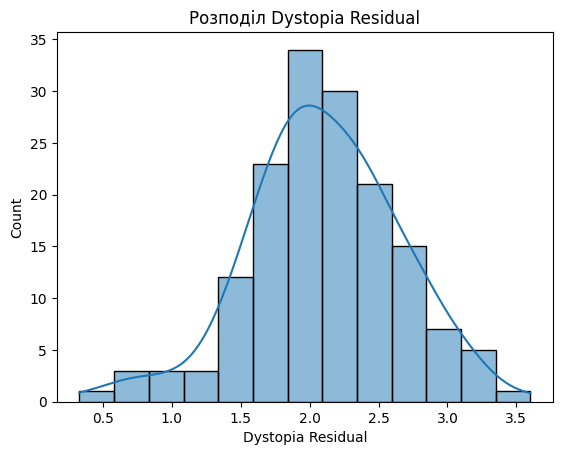

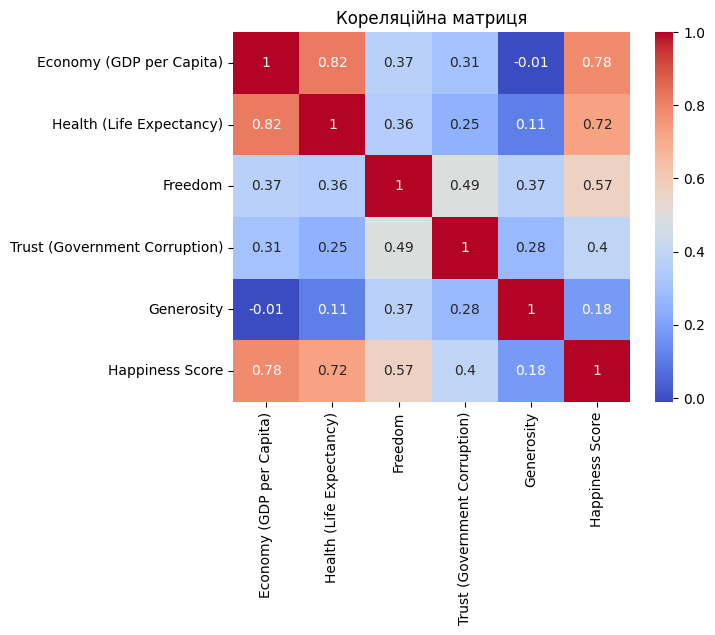

Оригінальні дані:
       Economy (GDP per Capita)  Health (Life Expectancy)     Freedom  \
count                158.000000                158.000000  158.000000   
mean                   0.846137                  0.630259    0.428615   
std                    0.403121                  0.247078    0.150693   
min                    0.000000                  0.000000    0.000000   
25%                    0.545808                  0.439185    0.328330   
50%                    0.910245                  0.696705    0.435515   
75%                    1.158448                  0.811013    0.549092   
max                    1.690420                  1.025250    0.669730   

       Trust (Government Corruption)  Generosity  Happiness Score  
count                     158.000000  158.000000       158.000000  
mean                        0.143422    0.237296         5.375734  
std                         0.120034    0.126685         1.145010  
min                         0.000000    0.000000    

In [2]:
# 1. Інсталяція та імпорт бібліотек
!pip install plotly==5.20.0
!pip install "jupyterlab>=3" "ipywidgets>=7.6"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# 2. Завантаження даних
df = pd.read_csv("/content/drive/MyDrive/Домашнє завдання/Лінійне програмування/HW_10_Manzar/2015.csv")
print("Файл успішно завантажено!")

# 3. Загальна інформація
print(df.info())
print(df.describe())

# 4. Розподіл числових ознак
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Розподіл {col}")
    plt.show()

# 5. Кореляційна матриця
features = ["Economy (GDP per Capita)", "Health (Life Expectancy)",
            "Freedom", "Trust (Government Corruption)",
            "Generosity", "Happiness Score"]

corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Кореляційна матриця")
plt.show()

# 6. Теплова мапа індексу щастя
fig = px.choropleth(df,
                    locations="Country",
                    color="Happiness Score",
                    locationmode="country names",
                    hover_name="Country",
                    hover_data=["Happiness Score"])
fig.update_layout(title="Happiness Score by Country (2015)")
fig.show()

# 9. Стандартизація даних
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(data_scaled, columns=features)

# 10. Порівняння статистик
print("Оригінальні дані:")
print(df[features].describe())
print("\nСтандартизовані дані:")
print(df_scaled.describe())

# 11. Кластеризація GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(df_scaled)
df["Cluster"] = clusters

# 12. Теплова мапа кластерів
fig = px.choropleth(df,
                    locations="Country",
                    color="Cluster",
                    locationmode="country names",
                    hover_name="Country")
fig.update_layout(title="Clusters of Countries by Happiness Factors")
fig.show()

# 13. Дослідження впливу альтернативних ознак
alt_features = ["Economy (GDP per Capita)", "Family", "Health (Life Expectancy)", "Freedom"]
data_scaled_alt = scaler.fit_transform(df[alt_features])
gmm_alt = GaussianMixture(n_components=3, random_state=42)
clusters_alt = gmm_alt.fit_predict(data_scaled_alt)
df["Cluster_alt"] = clusters_alt

fig = px.choropleth(df,
                    locations="Country",
                    color="Cluster_alt",
                    locationmode="country names",
                    hover_name="Country")
fig.update_layout(title="Clusters of Countries by Alternative Features")
fig.show()






## Висновки

1. Дані World Happiness Report 2015 успішно завантажені та проаналізовані.  
2. Розподіли числових ознак показали відхилення від нормального розподілу, що важливо враховувати при статистичному аналізі.  
3. Кореляційна матриця підтвердила сильний зв'язок між економічними показниками (GDP per Capita, Life Expectancy) та рівнем щастя.  
4. Географічна теплова мапа показала, що найбільш щасливі країни зосереджені у Північній Європі.  
5. Стандартизація даних дозволила привести ознаки до одного масштабу, що є необхідним для коректної кластеризації.  
6. Кластеризація методом Gaussian Mixture розділила країни на три групи, які загалом відповідають оригінальному розподілу за Happiness Score.  
7. Зміна набору ознак (наприклад, додавання Family) вплинула на результат кластеризації, що підтверджує важливість правильного вибору ознак для аналізу.  

### Загальний підсумок
Задача продемонструвала повний цикл аналізу даних: від завантаження та візуалізації до стандартизації та кластеризації. Отримані результати підтверджують, що економічні та соціальні фактори мають значний вплив на рівень щастя у країнах світу.
